In [5]:
from sklearn.datasets import make_classification
import numpy as np
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

In [6]:
import matplotlib.pyplot as plt

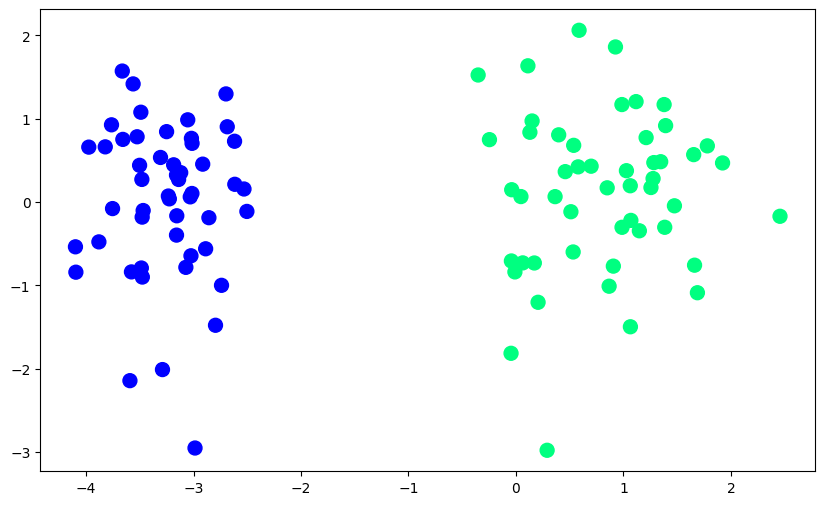

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,s=100,cmap="winter")
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression 
lor = LogisticRegression(penalty=None,solver="sag")
lor.fit(X,y)

E:\ai-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
E:\ai-ml\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [9]:
print(lor.coef_)
print(lor.intercept_)

[[4.76474406 0.20408182]]
[5.72667114]


In [10]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [11]:
x_input = np.linspace(X,0,1,axis=1)
y_input = m1 * x_input + b1

In [12]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [13]:
def gd(X,y):
    X = np.insert(X,0,1,axis=1)
    weight = np.ones(X.shape[1])
    lr = 0.5

    for i in range(2500):
        y_hat = sigmoid(np.dot(X,weight))
        weight = weight + lr * (np.dot((y - y_hat),X)/X.shape[0])

    return weight[1:],weight[0]

In [14]:
coef_,intercept_ = gd(X,y)

In [15]:
(coef_,intercept_)

(array([4.36410145, 0.17189254]), np.float64(5.148029492159727))

In [16]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [17]:
(m,b)

(np.float64(-25.388544075572273), np.float64(-29.949114409110653))

In [18]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m * x_input1 + b

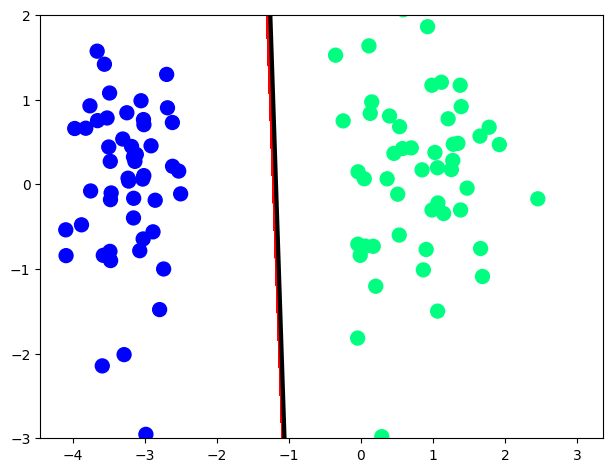

In [19]:
plt.plot(x_input.reshape(-1), y_input.reshape(-1), color='red', linewidth=3)
plt.plot(x_input1.reshape(-1), y_input1.reshape(-1), color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap="winter", s=100)
plt.tight_layout()
plt.ylim(-3,2)
plt.show()


In [20]:
import numpy as np

In [57]:
class LR:
    def __init__(self,lr=0.5,max_iter=2500):
        self.lr = lr
        self.max_iter = max_iter
        self.weight = None

    def sigmoid(self,x):
        return 1 / (1 + np.exp(-x))

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        self.weight = np.ones(X_train.shape[1])

        for _ in range(self.max_iter):
            y_hat = self.sigmoid(np.dot(X_train,self.weight))
            gd = (np.dot((y_train - y_hat),X_train)) / X_train.shape[0]
            self.weight += self.lr * gd  

        return self.weight[1:],self.weight[0]

    def predict(self,X_test):
        X_test = np.insert(X_test,0,1,axis=1)
        pro = self.sigmoid(np.dot(X_test,self.weight))
        return pro,(pro >= 0.5).astype(int)

In [58]:
modal = LR()

In [59]:
modal.fit(X,y)

(array([4.36410145, 0.17189254]), np.float64(5.148029492159727))

In [60]:
pro,y_pred = modal.predict(X)

In [61]:
y_pred

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [62]:
pro

array([9.99363563e-01, 9.95023318e-01, 9.92161272e-01, 7.10517256e-05,
       9.97306208e-01, 2.81660679e-03, 5.02226120e-05, 9.99108740e-01,
       9.85229155e-01, 2.28434804e-05, 3.79567856e-05, 4.26613616e-05,
       9.97271866e-01, 9.99964022e-01, 4.09892919e-05, 9.99744917e-01,
       9.96883634e-01, 2.46589360e-05, 9.97150554e-01, 4.50283084e-05,
       5.64070846e-06, 1.48580953e-05, 3.37692612e-04, 9.99998782e-01,
       5.55914962e-04, 9.99925820e-01, 3.71305619e-05, 9.28852357e-04,
       2.67172440e-06, 4.27574273e-05, 2.02493348e-04, 9.99995311e-01,
       9.99504422e-01, 9.99861130e-01, 9.99842683e-01, 9.93042629e-01,
       1.62457717e-03, 9.99935696e-01, 1.01634630e-04, 9.99943226e-01,
       2.85516091e-04, 1.96070462e-03, 3.31789746e-04, 9.99997817e-01,
       3.02495003e-03, 9.99988613e-01, 9.99263095e-01, 2.26767941e-04,
       6.70274602e-04, 2.12075494e-03, 9.99368904e-01, 9.93312152e-01,
       2.23494527e-04, 9.99976532e-01, 9.99999868e-01, 1.33539138e-04,
      